In [4]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import datetime
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import KernelPCA
import math
from utils import *

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

In [6]:
def make_ts_power_by_county(state,
                  county,
                  start_year,
                  start_month,
                  start_day,
                  end_year,
                  end_month,
                  end_day,
                  data_directory = '../Data/eaglei_data'):
    """
    Generate a time series dataframe of power outages for a specific state's counties within a given date range.

    This function reads yearly CSV files containing power outage data, filters the data for a specified state,
    aggregates the number of customers without power, and returns a time series dataframe for the specified date range.

    Parameters:
    state (str): The state for which to generate the time series data.
    start_year (int): The starting year of the date range.
    start_month (int): The starting month of the date range.
    start_day (int): The starting day of the date range.
    end_year (int): The ending year of the date range.
    end_month (int): The ending month of the date range.
    end_day (int): The ending day of the date range.
    data_directory (str, optional): The directory containing the CSV files. Default is './data/eaglei_data'.

    Returns:
    pd.DataFrame: A dataframe with a datetime index ('time') and a column 'customers_out' representing the number of customers without power.

    Raises:
    FileNotFoundError: If any of the CSV files for the specified years do not exist in the data directory.
    """
    
    df_list = []
    for year in range(start_year, end_year + 1):
        # Construct the filename
        file_name = f"eaglei_outages_{year}.csv"
        file_path = os.path.join(data_directory, file_name)
        # Check if the file exists
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"The file {file_name} does not exist in the directory {data_directory}.")
    
        # Read the CSV file into a dataframe
        df = pd.read_csv(file_path)
        df['run_start_time'] = pd.to_datetime(df['run_start_time'])
        df.dropna(subset=['customers_out'],inplace=True)
        
        df_state = df[(df['state']==state) & (df['county']==county)].copy(deep=True)
        df_state_ts_cus = df_state.groupby('run_start_time')['customers_out'].sum().reset_index()
        df_state_ts_cus.drop(df_state_ts_cus.index[-1], inplace=True)
        df_state_ts_cus.set_index('run_start_time', inplace=True)
        df_state_ts_cus.rename_axis('time', inplace=True)
    
        
        # Append the dataframe to the list
        df_list.append(df_state_ts_cus)
    
    # Concatenate all dataframes in the list into a single dataframe
    concat_df = pd.concat(df_list, ignore_index=False)
    start_date = pd.Timestamp(year=start_year, month=start_month, day=start_day)
    end_date = pd.Timestamp(year=end_year, month=end_month, day=end_day+1)
    # Slice the dataframe
    df_state_ts_power = concat_df.loc[start_date:end_date].copy(deep=True)
    df_state_ts_power.drop(df_state_ts_power.index[-1], inplace=True)

    return df_state_ts_power

def make_ts_events_by_county(state, county, event_types, start_year, start_month, start_day, end_year, end_month, end_day, df):
    """
    Construct a DataFrame with 15-minute intervals indicating event occurrence.
   
    Parameters:
    - df (pd.DataFrame): The NOAA StormEvent database.
    - state (str): The state to filter (e.g., "Texas").
    - event_types (list): The event types to filter (e.g., ["Winter Storm", "Hurricane"]).
    - start_year (int): The start year for the new DataFrame.
    - start_month (int): The start month for the new DataFrame.
    - start_day (int): The start day for the new DataFrame.
    - end_year (int): The end year for the new DataFrame.
    - end_month (int): The end month for the new DataFrame.
    - end_day (int): The end day for the new DataFrame.
   
    Returns:
    - pd.DataFrame: A DataFrame with 15-minute intervals and event counts.
    """
    # Generate the time range for the new DataFrame
    start_date = datetime(start_year, start_month, start_day)
    end_date = datetime(end_year, end_month, end_day, 23, 45)  # Include the last time interval
    time_index = pd.date_range(start=start_date, end=end_date, freq='15min')
   
    # Create the new DataFrame with 15-minute intervals
    new_df = pd.DataFrame({'time': time_index})
    
    # Initialize event count columns for each event type
    for event_type in event_types:
        new_df[f'event_count {event_type}'] = 0  # Initialize event counts to 0
   
    # Convert BEGIN and END times into datetime objects
    df['BEGIN_DATETIME'] = pd.to_datetime(
        df['BEGIN_YEARMONTH'].astype(str) + df['BEGIN_DAY'].astype(str).str.zfill(2) +
        df['BEGIN_TIME'].astype(str).str.zfill(4), format='%Y%m%d%H%M'
    )
    df['END_DATETIME'] = pd.to_datetime(
        df['END_YEARMONTH'].astype(str) + df['END_DAY'].astype(str).str.zfill(2) +
        df['END_TIME'].astype(str).str.zfill(4), format='%Y%m%d%H%M'
    )
    
    # Filter the NOAA data for the specified state and event type
    filtered_df = df[
        (df['STATE'] == state) &
        (df['CZ_NAME'] == county) &
        (df['EVENT_TYPE'].isin(event_types)) & 
        (df['END_DATETIME'] >= start_date) & 
        (df['BEGIN_DATETIME'] <= end_date)
    ].copy(deep=True)
   
    # Iterate through the events and assign them to the closest time interval in the new DataFrame
    for event_type in event_types:
        event_subset = filtered_df[filtered_df['EVENT_TYPE']==event_type]
        
        for _, row in event_subset.iterrows():
            event_start = row['BEGIN_DATETIME']
            event_end = row['END_DATETIME']
       
            # Round the start and end times to the nearest 15-minute interval
            event_start_rounded = event_start.round('15min')
            event_end_rounded = event_end.round('15min')
       
            # Find the indices in the new DataFrame for the rounded times
            start_idx = new_df['time'].searchsorted(event_start_rounded)
            end_idx = new_df['time'].searchsorted(event_end_rounded)
       
            # Increment the event count for the affected time intervals
            if start_idx < len(new_df) and end_idx <= len(new_df):
                new_df.loc[start_idx:end_idx, f'event_count {event_type}'] += 1
   
    # Add YEAR, MONTH, DAY columns
    new_df['YEAR'] = new_df['time'].dt.year
    new_df['MONTH'] = new_df['time'].dt.month
    new_df['DAY'] = new_df['time'].dt.day
    
    # Re-order the columns to make sure the YEAR, MONTH, DAY, time start first
    cols_order = ['YEAR', 'MONTH', 'DAY', 'time'] + [col for col in new_df.columns if col not in ['YEAR', 'MONTH', 'DAY', 'time']]
    new_df = new_df[cols_order]

    
    # Return the new_df
    return new_df

def combine_agg_ts_by_county(state,
                   county,
                   start_year,
                   start_month,
                   start_day,
                   end_year,
                   end_month,
                   end_day,
                   data_directory_power = '../Data/eaglei_data',
                   data_directory_events = '../Data/NOAA_StormEvents'):
    """
    Combine and aggregate time series data of power outages and weather events for a specific state within a given date range.

    This function generates time series data for power outages and weather events, aggregates them by hour and day,
    and merges the aggregated data into two combined dataframes.

    Parameters:
    state (str): The state for which to generate the time series data.
    start_year (int): The starting year of the date range.
    start_month (int): The starting month of the date range.
    start_day (int): The starting day of the date range.
    end_year (int): The ending year of the date range.
    end_month (int): The ending month of the date range.
    end_day (int): The ending day of the date range.
    data_directory_power (str, optional): The directory containing the power outage CSV files. Default is './eaglei_data'.
    data_directory_events (str, optional): The directory containing the weather events CSV files. Default is './NOAA_StormEvents'.

    Returns:
    tuple: Two dataframes for each county in state - the first aggregated by hour and the second aggregated by day, both containing combined time series data of power outages and weather events.

    Raises:
    FileNotFoundError: If any of the required CSV files do not exist in the specified directories.
    """

    df_county_ts_power = make_ts_power_by_county(state = state,
                                      county = county,
                                      start_year = start_year,
                                      start_month = start_month,
                                      start_day = start_day,
                                      end_year = end_year,
                                      end_month = end_month,
                                      end_day = end_day,
                                      data_directory = data_directory_power)
    
    df_county_ts_power_hr = aggregate_ts(df_county_ts_power, 'hour')
    df_county_ts_power_day = aggregate_ts(df_county_ts_power, 'day')
    
    
    
    df_events = pd.read_csv(os.path.join(data_directory_events, "StormEvents_2014_2024.csv"))
    df_county_events=df_events[(df_events['STATE']== state.upper()) & (df_events['CZ_NAME']== county.upper())].copy(deep=True)
    event_types_county = list(df_county_events['EVENT_TYPE'].unique())
    
    df_county_ts_events = make_ts_events_by_county(state = state.upper(),
                                        county = county.upper(),
                                        event_types= event_types_county,
                                        start_year = start_year,
                                        start_month = start_month,
                                        start_day = start_day,
                                        end_year = end_year,
                                        end_month = end_month,
                                        end_day = end_day,
                                        df=df_events)
    df_county_ts_events['time'] = pd.to_datetime(df_county_ts_events['time'])
    df_county_ts_events.set_index('time', inplace=True)
    df_county_ts_events.drop(columns=['YEAR', 'DAY', 'MONTH'], inplace=True)

    df_county_ts_events_hr = aggregate_ts(df_county_ts_events, 'hour')
    df_county_ts_events_day = aggregate_ts(df_county_ts_events, 'day')

    df_county_ts_comb_hr = pd.merge(df_county_ts_events_hr, df_county_ts_power_hr, left_index=True, right_index=True)
    df_county_ts_comb_day = pd.merge(df_county_ts_events_day, df_county_ts_power_day, left_index=True, right_index=True)
    
    return df_county_ts_comb_hr, df_county_ts_comb_day

In [126]:
state = 'Tennessee'
county = 'Davidson'
start_year = 2016
start_month = 1
start_day = 1
end_year = 2021
end_month = 12
end_day = 30

df_TN_Davidson_ts_comb_hr, df_TN_Davidson_ts_comb_day = combine_agg_ts(state = state,
              start_year = start_year,
                start_month = start_month,
                start_day = start_day,
                end_year = end_year,
                end_month = end_month,
                end_day = end_day,
                data_directory_power = '../data/eaglei_data',
                data_directory_events = '../data/NOAA_StormEvents')

In [127]:
df_TN_Davidson_ts_comb_hr

,event_count Winter Storm,event_count Thunderstorm Wind,event_count Ice Storm,event_count Winter Weather,event_count Heavy Snow,event_count High Wind,event_count Flash Flood,event_count Hail,event_count Tornado,event_count Flood,...,event_count Blizzard,event_count Extreme Cold/Wind Chill,event_count Freezing Fog,event_count Heat,event_count Excessive Heat,event_count Drought,event_count Wildfire,event_count Astronomical Low Tide,event_count Debris Flow,customers_out
time,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.00
2016-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.25
2016-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.00
2016-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.00
2016-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-30 19:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,237.00
2021-12-30 20:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,268.75
2021-12-30 21:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,324.25


In [128]:
df_TN_Davidson_ts_comb_hr.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
event_count Winter Storm,52584.0,0.088482,1.642200,0.0,0.0,0.00,0.0000,48.00
event_count Thunderstorm Wind,52584.0,0.018832,0.245543,0.0,0.0,0.00,0.0000,16.25
event_count Ice Storm,52584.0,0.004426,0.195672,0.0,0.0,0.00,0.0000,11.00
event_count Winter Weather,52584.0,0.152290,1.706615,0.0,0.0,0.00,0.0000,46.00
event_count Heavy Snow,52584.0,0.098338,1.694312,0.0,0.0,0.00,0.0000,47.00
event_count High Wind,52584.0,0.001127,0.035090,0.0,0.0,0.00,0.0000,2.75
event_count Flash Flood,52584.0,0.026358,0.311960,0.0,0.0,0.00,0.0000,12.00
event_count Hail,52584.0,0.003918,0.070377,0.0,0.0,0.00,0.0000,5.50
event_count Tornado,52584.0,0.001588,0.046381,0.0,0.0,0.00,0.0000,4.25
event_count Flood,52584.0,0.029049,0.455434,0.0,0.0,0.00,0.0000,16.00


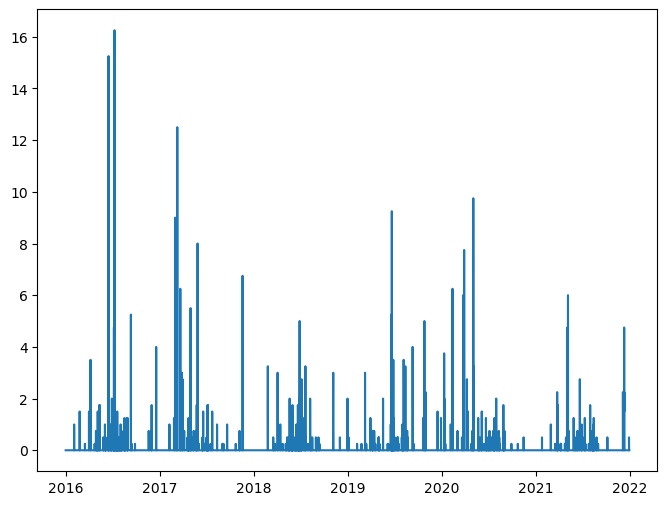

In [129]:
plt.plot(df_TN_Davidson_ts_comb_hr["event_count Thunderstorm Wind"])

In [130]:
imputer = SimpleImputer(missing_values=np.nan)
df = df_TN_Davidson_ts_comb_hr
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [131]:
df

,event_count Winter Storm,event_count Thunderstorm Wind,event_count Ice Storm,event_count Winter Weather,event_count Heavy Snow,event_count High Wind,event_count Flash Flood,event_count Hail,event_count Tornado,event_count Flood,...,event_count Blizzard,event_count Extreme Cold/Wind Chill,event_count Freezing Fog,event_count Heat,event_count Excessive Heat,event_count Drought,event_count Wildfire,event_count Astronomical Low Tide,event_count Debris Flow,customers_out
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.00
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.25
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.00
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.00
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52579,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,237.00
52580,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,268.75
52581,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,324.25
52582,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,392.25


In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
df_scaled = scaler.fit_transform(df.to_numpy())
df_scaled = pd.DataFrame(test_scaled, columns=list(df.columns))

target_scaler = MinMaxScaler(feature_range=(0,1))

df_scaled[['customers_out']] = target_scaler.fit_transform(df[['customers_out']].to_numpy())

df_scaled = df_scaled.astype(float)
print(df_scaled.head())

Here we can introduce our combined aggregated timeseries

In [ ]:
df = pd.read_csv(csv_path)
# Slice [start:stop:step], starting from index 5 take every 6th record.
df = df[5::6]

#pop removes the date time column to be stored in date_time as a Dataseries
date_time = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')

In [132]:
#pd.to_datetime(df_TN_Davidson_ts_comb_hr.index, format='%Y-%m-%d %H:%M:%S')
date_time = pd.Series(df_TN_Davidson_ts_comb_hr.index.values, name = 'Date Time')

In [ ]:
#pop removes the date time column to be stored in date_time as a Dataseries
date_time = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')

To inspect and possibly cleanup:

In [32]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
event_count Winter Storm,52584.0,0.001669,0.040685,0.0,0.0,0.0,0.0,1.00
event_count Thunderstorm Wind,52584.0,0.001269,0.044119,0.0,0.0,0.0,0.0,4.25
event_count Hail,52584.0,0.000181,0.014045,0.0,0.0,0.0,0.0,2.50
event_count Winter Weather,52584.0,0.004279,0.064835,0.0,0.0,0.0,0.0,1.00
event_count Lightning,52584.0,0.000052,0.003615,0.0,0.0,0.0,0.0,0.25
event_count Flash Flood,52584.0,0.001074,0.031086,0.0,0.0,0.0,0.0,1.75
event_count Flood,52584.0,0.000342,0.016745,0.0,0.0,0.0,0.0,1.00
event_count Strong Wind,52584.0,0.000523,0.021469,0.0,0.0,0.0,0.0,1.00
event_count Tornado,52584.0,0.000086,0.007709,0.0,0.0,0.0,0.0,1.25
event_count Heavy Rain,52584.0,0.003718,0.133847,0.0,0.0,0.0,0.0,6.00


In [91]:
df.drop(['event_count High Wind','event_count Excessive Heat','event_count Heavy Snow'], axis=1 , inplace = True)

In [92]:
df

,event_count Winter Storm,event_count Thunderstorm Wind,event_count Hail,event_count Winter Weather,event_count Lightning,event_count Flash Flood,event_count Flood,event_count Strong Wind,event_count Tornado,event_count Heavy Rain,event_count Drought,event_count Funnel Cloud,event_count Heat,event_count Extreme Cold/Wind Chill,customers_out,Day sin,Day cos,Year sin,Year cos
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.250000,-1.407890e-12,1.000000,-0.002666,0.999996
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.000000,2.588190e-01,0.965926,-0.001950,0.999998
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,5.000000e-01,0.866025,-0.001233,0.999999
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,7.071068e-01,0.707107,-0.000516,1.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,8.660254e-01,0.500000,0.000201,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52579,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.500000,-9.659258e-01,0.258819,-0.014077,0.999901
52580,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.750000,-8.660254e-01,0.500000,-0.013360,0.999911
52581,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36.750000,-7.071068e-01,0.707107,-0.012644,0.999920
52582,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.500000,-5.000000e-01,0.866025,-0.011927,0.999929


Add a timestamp in seconds:

In [135]:
timestamp_s = date_time.map(pd.Timestamp.timestamp)

We add 4 columns with periodic information about the time of day, maybe not needed if our data is taken in 6 hour cadence?

In [136]:
day = 24*60*60
year = (365.2425)*day

df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

In [137]:
column_indices = {name: i for i, name in enumerate(df.columns)}

n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

We normalize our features below: (we can probably use a scaler for this too)

In [138]:
train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

In [139]:
train_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
event_count Winter Storm,36808.0,-2.934213e-17,1.0,-0.049053,-0.049053,-0.049053,-0.049053,35.900916
event_count Thunderstorm Wind,36808.0,-2.277876e-17,1.0,-0.077947,-0.077947,-0.077947,-0.077947,61.899174
event_count Ice Storm,36808.0,-7.721612e-19,1.0,-0.020448,-0.020448,-0.020448,-0.020448,50.156940
event_count Winter Weather,36808.0,-2.470916e-17,1.0,-0.092213,-0.092213,-0.092213,-0.092213,24.909036
event_count Heavy Snow,36808.0,2.934213e-17,1.0,-0.057638,-0.057638,-0.057638,-0.057638,23.989908
event_count High Wind,36808.0,-7.721612e-18,1.0,-0.034771,-0.034771,-0.034771,-0.034771,67.835972
event_count Flash Flood,36808.0,1.081026e-17,1.0,-0.088127,-0.088127,-0.088127,-0.088127,33.666087
event_count Hail,36808.0,1.544322e-17,1.0,-0.054541,-0.054541,-0.054541,-0.054541,75.572550
event_count Tornado,36808.0,6.177290e-18,1.0,-0.035496,-0.035496,-0.035496,-0.035496,64.220255
event_count Flood,36808.0,-2.316484e-17,1.0,-0.073582,-0.073582,-0.073582,-0.073582,29.445682


In [140]:
train_df

,event_count Winter Storm,event_count Thunderstorm Wind,event_count Ice Storm,event_count Winter Weather,event_count Heavy Snow,event_count High Wind,event_count Flash Flood,event_count Hail,event_count Tornado,event_count Flood,...,event_count Excessive Heat,event_count Drought,event_count Wildfire,event_count Astronomical Low Tide,event_count Debris Flow,customers_out,Day sin,Day cos,Year sin,Year cos
0,-0.049053,-0.077947,-0.020448,-0.092213,-0.057638,-0.034771,-0.088127,-0.054541,-0.035496,-0.073582,...,-0.047384,-0.285474,-0.0166,-0.017974,-0.051352,-0.199137,-0.000236,1.414246,-0.040609,1.357155
1,-0.049053,-0.077947,-0.020448,-0.092213,-0.057638,-0.034771,-0.088127,-0.054541,-0.035496,-0.073582,...,-0.047384,-0.285474,-0.0166,-0.017974,-0.051352,-0.200558,0.365797,1.366061,-0.039588,1.357157
2,-0.049053,-0.077947,-0.020448,-0.092213,-0.057638,-0.034771,-0.088127,-0.054541,-0.035496,-0.073582,...,-0.047384,-0.285474,-0.0166,-0.017974,-0.051352,-0.194913,0.706884,1.224786,-0.038568,1.357159
3,-0.049053,-0.077947,-0.020448,-0.092213,-0.057638,-0.034771,-0.088127,-0.054541,-0.035496,-0.073582,...,-0.047384,-0.285474,-0.0166,-0.017974,-0.051352,-0.194913,0.999783,1.000052,-0.037548,1.357159
4,-0.049053,-0.077947,-0.020448,-0.092213,-0.057638,-0.034771,-0.088127,-0.054541,-0.035496,-0.073582,...,-0.047384,-0.285474,-0.0166,-0.017974,-0.051352,-0.198243,1.224532,0.707172,-0.036528,1.357160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36803,-0.049053,-0.077947,-0.020448,-0.092213,-0.057638,-0.034771,-0.088127,-0.054541,-0.035496,-0.073582,...,-0.047384,-0.285474,-0.0166,-0.017974,-0.051352,-0.142083,0.365797,-1.365865,1.311390,0.400750
36804,-0.049053,-0.077947,-0.020448,-0.092213,-0.057638,-0.034771,-0.088127,-0.054541,-0.035496,-0.073582,...,-0.047384,-0.285474,-0.0166,-0.017974,-0.051352,-0.146266,-0.000236,-1.414051,1.311717,0.399794
36805,-0.049053,-0.077947,-0.020448,-0.092213,-0.057638,-0.034771,-0.088127,-0.054541,-0.035496,-0.073582,...,-0.047384,-0.285474,-0.0166,-0.017974,-0.051352,0.449319,-0.366268,-1.365865,1.312043,0.398838
36806,-0.049053,-0.077947,-0.020448,-0.092213,-0.057638,-0.034771,-0.088127,-0.054541,-0.035496,-0.073582,...,-0.047384,-0.285474,-0.0166,-0.017974,-0.051352,-0.009664,-0.707355,-1.224591,1.312368,0.397881


We plot our normalized features in a _Violin_ plot

C:\Users\cacereje\AppData\Local\Temp\ipykernel_35392\3214313372.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(df.keys(), rotation=90)


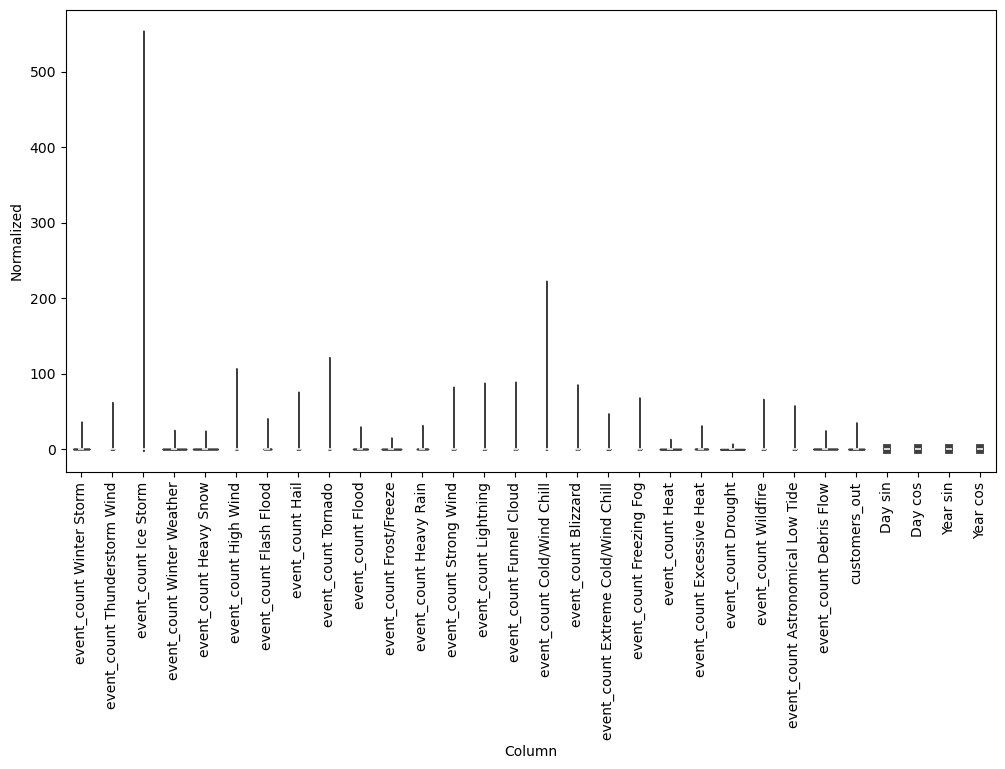

In [141]:
df_std = (df - train_mean) / train_std
df_std = df_std.melt(var_name='Column', value_name='Normalized')
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
_ = ax.set_xticklabels(df.keys(), rotation=90)

## SARIMA

In [39]:
import statsmodels.tsa.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima

Here `y` will be the timeseries

In [38]:
y = df['customers_out'].values

In [40]:
auto_arima(y, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=883879.501, Time=20.16 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=885980.196, Time=1.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=885595.413, Time=1.36 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=885467.256, Time=3.19 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=885978.196, Time=0.53 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=884551.003, Time=10.96 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=884451.059, Time=13.42 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=882365.813, Time=65.07 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=883623.752, Time=17.42 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=882152.940, Time=71.66 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=883385.116, Time=25.63 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=882043.798, Time=100.14 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=882794.747, Time=32.89 sec
 ARIMA(5,1,3)(0,0,0)[0] intercept   : AIC=881698.872, Time=114.

ARIMA(order=(5, 1, 3), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

In [41]:
# This is how we fit the model
model = sm.ARIMA(y, order = (5, 1, 3)).fit()
model.summary()

c:\Users\cacereje\AppData\Local\miniconda3\envs\erdos_spring_2025\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\cacereje\AppData\Local\miniconda3\envs\erdos_spring_2025\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\cacereje\AppData\Local\miniconda3\envs\erdos_spring_2025\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                52584
Model:                 ARIMA(5, 1, 3)   Log Likelihood             -440839.565
Date:                Wed, 26 Mar 2025   AIC                         881697.130
Time:                        16:08:36   BIC                         881776.961
Sample:                             0   HQIC                        881722.078
                              - 52584                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3392      0.001    579.700      0.000       0.338       0.340
ar.L2         -0.4063      0.001   -375.387      0.000      -0.408      -0.404
ar.L3          0.6550      0.001    714.473      0.000       0.653       0.657
ar.L4          0.1443      0.000    410.561      0.000       0.144       0.145
ar.L5          0.0334      0.001     54.579      0.000       0.032       0.035
ma.L1         -0.4383      0.001   -597.871      0.000      -0.440      -0.437
ma.L2          0.3593      0.001    302.935      0.000       0.357       0.362
ma.L3         -0.8166      0.001  -1332.764      0.000      -0.818      -0.815
sigma2      1.137e+06    166.887   6812.621      0.000    1.14e+06    1.14e+06
===================================================================================
Ljung-Box (L1) (Q):                   1.26   Jarque-Bera (JB):       56916410847.36
Prob(Q):                              0.26   Prob(JB):                         0.00
Heteroskedasticity (H):              24.20   Skew:                            28.64
Prob(H) (two-sided):                  0.00   Kurtosis:                      5099.53
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [42]:
# to generate new predictions:
model.forecast(10)

array([-104.50326141,   42.33631793,   89.8666612 ,  -41.59506122,
        -28.66159025,   77.00551366,   33.25405465,  -33.42705528,
         28.41315515,   63.50420733])

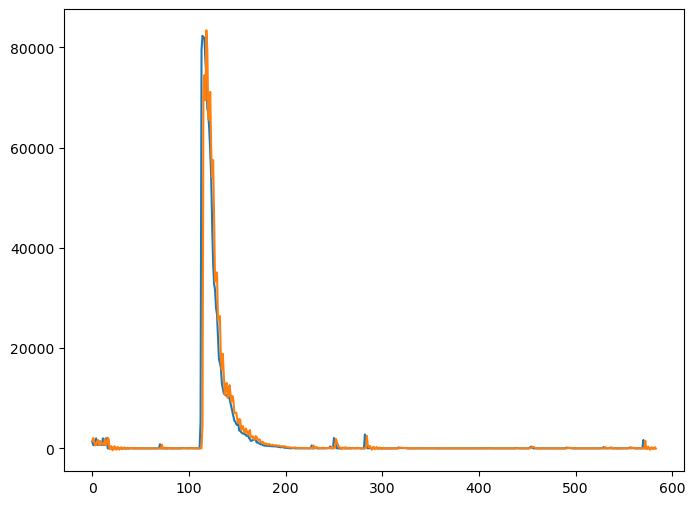

In [58]:
# to see the fit on the training data
plt.plot(range(52583-52000), y[52001:])
plt.plot(range(52584-52000), model.fittedvalues[52000:])
plt.show()

For SARIMA we do

In [ ]:
model = sm.ARIMA(y, order = (p, d, q), seasonal_order=(P, D, Q, s)).fit()

## All the window stuff

We create the class `WindowGenerator` used in all the NN forecasting methods below.

In [142]:
class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=train_df, val_df=val_df, test_df=test_df,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}'])

In [143]:
def split_window(self, features):
  inputs = features[:, self.input_slice, :]
  labels = features[:, self.labels_slice, :]
  if self.label_columns is not None:
    labels = tf.stack(
        [labels[:, :, self.column_indices[name]] for name in self.label_columns],
        axis=-1)

  # Slicing doesn't preserve static shape information, so set the shapes
  # manually. This way the `tf.data.Datasets` are easier to inspect.
  inputs.set_shape([None, self.input_width, None])
  labels.set_shape([None, self.label_width, None])

  return inputs, labels

WindowGenerator.split_window = split_window

### Change column name here

In [144]:
def plot(self, model=None, plot_col='customers_out', max_subplots=3):
  inputs, labels = self.example
  plt.figure(figsize=(12, 8))
  plot_col_index = self.column_indices[plot_col]
  max_n = min(max_subplots, len(inputs))
  for n in range(max_n):
    plt.subplot(max_n, 1, n+1)
    plt.ylabel(f'{plot_col} [normed]')
    plt.plot(self.input_indices, inputs[n, :, plot_col_index],
             label='Inputs', marker='.', zorder=-10)

    if self.label_columns:
      label_col_index = self.label_columns_indices.get(plot_col, None)
    else:
      label_col_index = plot_col_index

    if label_col_index is None:
      continue

    plt.scatter(self.label_indices, labels[n, :, label_col_index],
                edgecolors='k', label='Labels', c='#2ca02c', s=64)
    if model is not None:
      predictions = model(inputs)
      plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                  marker='X', edgecolors='k', label='Predictions',
                  c='#ff7f0e', s=64)

    if n == 0:
      plt.legend()

  plt.xlabel('Time [h]')

WindowGenerator.plot = plot

In [145]:
def make_dataset(self, data):
  data = np.array(data, dtype=np.float32)
  ds = tf.keras.utils.timeseries_dataset_from_array(
      data=data,
      targets=None,
      sequence_length=self.total_window_size,
      sequence_stride=1,
      shuffle=True,
      batch_size=32,)

  ds = ds.map(self.split_window)

  return ds

WindowGenerator.make_dataset = make_dataset

The `WindowGenerator` object holds training, validation, and test data.

Add properties for accessing them as `tf.data.Dataset`s using the `make_dataset` method you defined earlier. Also, add a standard example batch for easy access and plotting:

In [146]:
@property
def train(self):
  return self.make_dataset(self.train_df)

@property
def val(self):
  return self.make_dataset(self.val_df)

@property
def test(self):
  return self.make_dataset(self.test_df)

@property
def example(self):
  """Get and cache an example batch of `inputs, labels` for plotting."""
  result = getattr(self, '_example', None)
  if result is None:
    # No example batch was found, so get one from the `.train` dataset
    result = next(iter(self.train))
    # And cache it for next time
    self._example = result
  return result

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

### Here we might need to adjust the column name

In [147]:
single_step_window = WindowGenerator(
    input_width=1, label_width=1, shift=1,
    label_columns=['customers_out'])
single_step_window

Total window size: 2
Input indices: [0]
Label indices: [1]
Label column name(s): ['customers_out']

## Baseline model:

In [148]:
class Baseline(tf.keras.Model):
  def __init__(self, label_index=None):
    super().__init__()
    self.label_index = label_index

  def call(self, inputs):
    if self.label_index is None:
      return inputs
    result = inputs[:, :, self.label_index]
    return result[:, :, tf.newaxis]

### Change column name here

In [149]:
baseline = Baseline(label_index=column_indices['customers_out'])

baseline.compile(loss=tf.keras.losses.MeanSquaredError(),
                 metrics=[tf.keras.metrics.MeanAbsoluteError()])

val_performance = {}
performance = {}
val_performance['Baseline'] = baseline.evaluate(single_step_window.val, return_dict=True)
performance['Baseline'] = baseline.evaluate(single_step_window.test, verbose=0, return_dict=True)

329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1557 - mean_absolute_error: 0.1065


### Adjust column name here

In [150]:
wide_window = WindowGenerator(
    input_width=24, label_width=24, shift=1,
    label_columns=['customers_out'])

wide_window

Total window size: 25
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Label column name(s): ['customers_out']

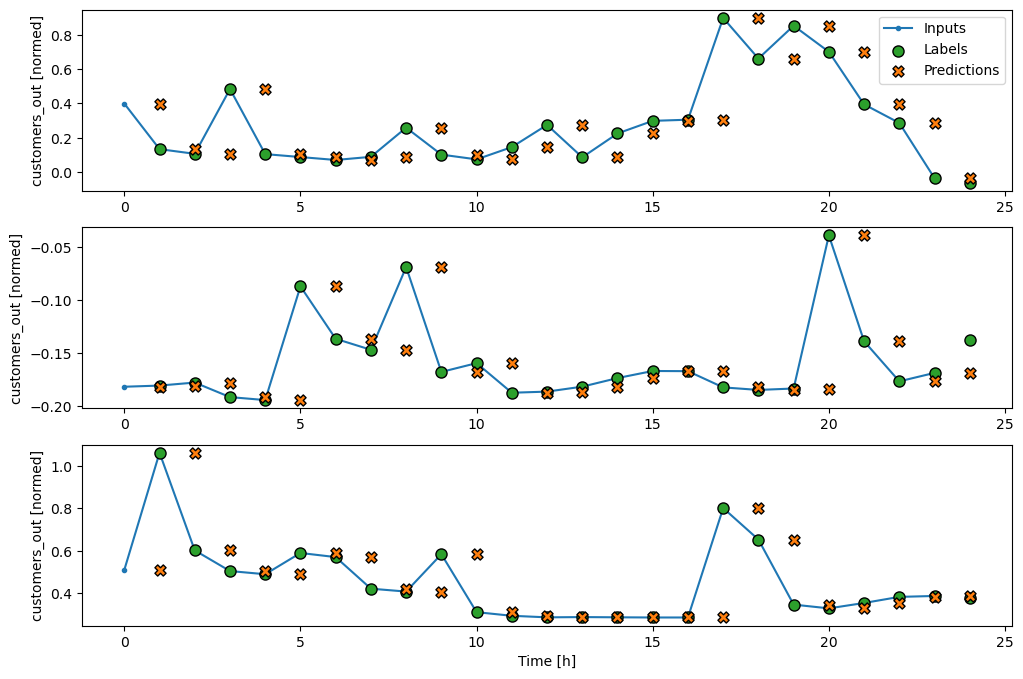

In [151]:
wide_window.plot(baseline)

## Linear model

In [152]:
linear = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1)
])

In [153]:
MAX_EPOCHS = 20

def compile_and_fit(model, window, patience=2):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history

In [154]:
history = compile_and_fit(linear, single_step_window)

val_performance['Linear'] = linear.evaluate(single_step_window.val, return_dict=True)
performance['Linear'] = linear.evaluate(single_step_window.test, verbose=0, return_dict=True)

Epoch 1/20
1151/1151 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.8363 - mean_absolute_error: 0.4241 - val_loss: 7.8018 - val_mean_absolute_error: 0.4465
Epoch 2/20
1151/1151 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8321 - mean_absolute_error: 0.2495 - val_loss: 1.8126 - val_mean_absolute_error: 0.2815
Epoch 3/20
1151/1151 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3919 - mean_absolute_error: 0.1659 - val_loss: 0.4921 - val_mean_absolute_error: 0.1738
Epoch 4/20
1151/1151 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1664 - mean_absolute_error: 0.1118 - val_loss: 0.2753 - val_mean_absolute_error: 0.1256
Epoch 5/20
1151/1151 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0755 - mean_absolute_error: 0.0815 - val_loss: 0.2318 - val_mean_absolute_error: 0.1092
Epoch 6/20
1151/1151 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0484 - mean_absolute_error: 0.0686 - val_loss: 0.2306 - val_mean_absolute_error: 0.1078
Epoch 7/20
1151/1151 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0447 - mean_absolute_err

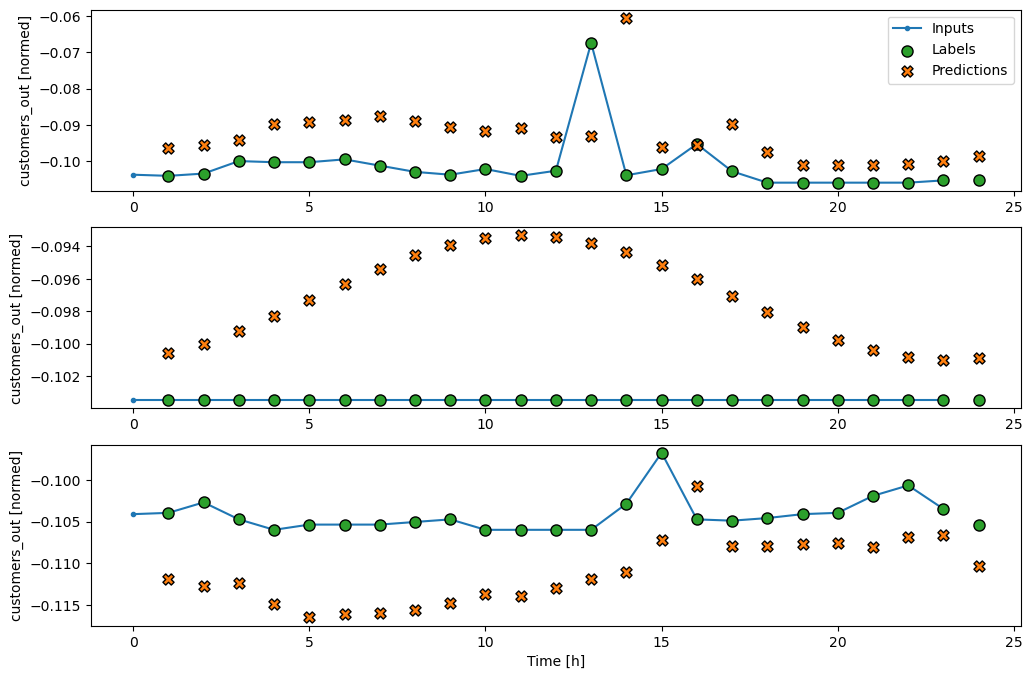

In [113]:
wide_window.plot(linear)

## Multistep dense

In [157]:
CONV_WIDTH = 3
conv_window = WindowGenerator(
    input_width=CONV_WIDTH,
    label_width=1,
    shift=1,
    label_columns=['customers_out'])

conv_window

Total window size: 4
Input indices: [0 1 2]
Label indices: [3]
Label column name(s): ['customers_out']

In [158]:
multi_step_dense = tf.keras.Sequential([
    # Shape: (time, features) => (time*features)
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1),
    # Add back the time dimension.
    # Shape: (outputs) => (1, outputs)
    tf.keras.layers.Reshape([1, -1]),
])

In [160]:
history = compile_and_fit(multi_step_dense, conv_window)

IPython.display.clear_output()
val_performance['Multi step dense'] = multi_step_dense.evaluate(conv_window.val, return_dict=True)
performance['Multi step dense'] = multi_step_dense.evaluate(conv_window.test, verbose=0, return_dict=True)

329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2068 - mean_absolute_error: 0.1242


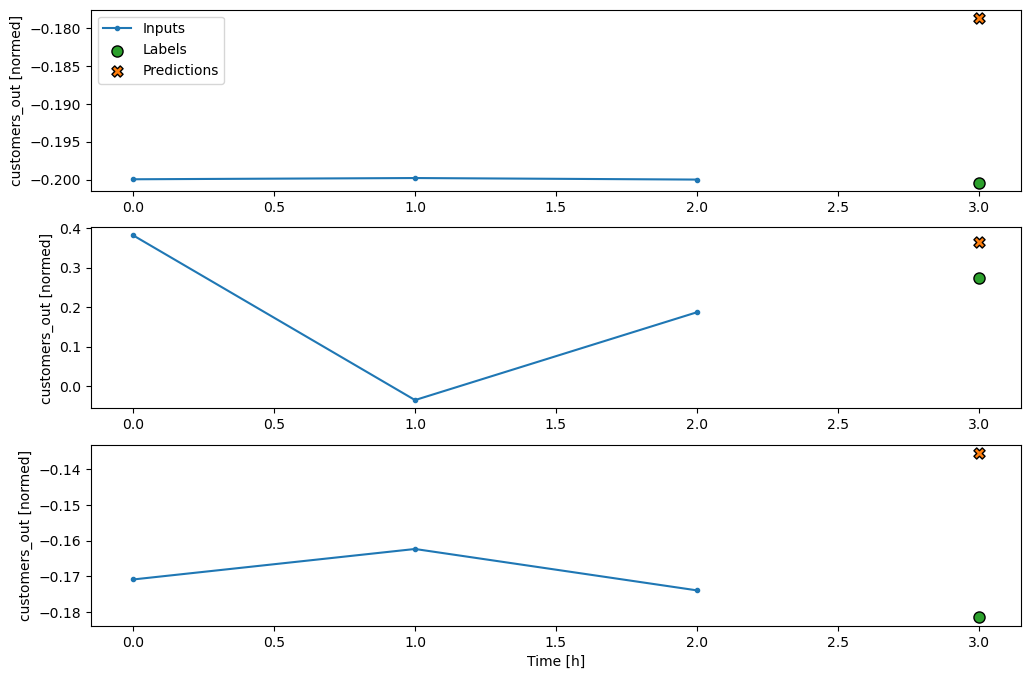

In [161]:
conv_window.plot(multi_step_dense)

## Convolutional Neural Network

In [162]:
conv_model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=32,
                           kernel_size=(CONV_WIDTH,),
                           activation='relu'),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1),
])

In [163]:
history = compile_and_fit(conv_model, conv_window)

IPython.display.clear_output()
val_performance['Conv'] = conv_model.evaluate(conv_window.val, return_dict=True)
performance['Conv'] = conv_model.evaluate(conv_window.test, verbose=0, return_dict=True)

329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4569 - mean_absolute_error: 0.1624


### Change column name here

In [164]:
LABEL_WIDTH = 24
INPUT_WIDTH = LABEL_WIDTH + (CONV_WIDTH - 1)
wide_conv_window = WindowGenerator(
    input_width=INPUT_WIDTH,
    label_width=LABEL_WIDTH,
    shift=1,
    label_columns=['customers_out'])

wide_conv_window

Total window size: 27
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
Label indices: [ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26]
Label column name(s): ['customers_out']

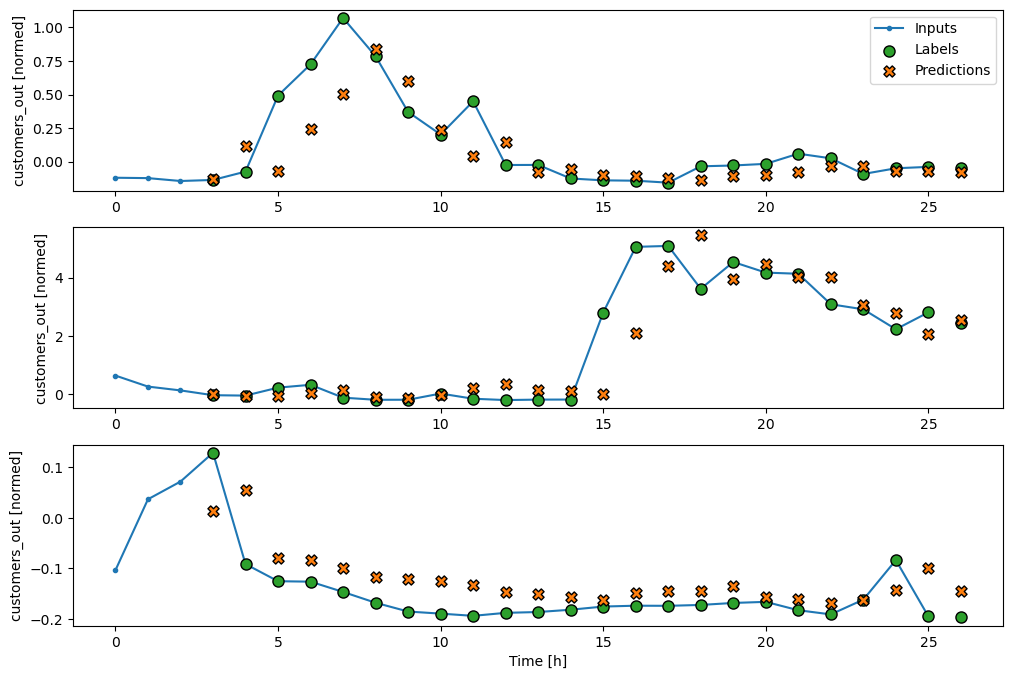

In [165]:
wide_conv_window.plot(conv_model)

## Recurrent Neural Network

In [166]:
lstm_model = tf.keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    tf.keras.layers.LSTM(32, return_sequences=True),
    # Shape => [batch, time, features]
    tf.keras.layers.Dense(units=1)
])

In [167]:
history = compile_and_fit(lstm_model, wide_window)

IPython.display.clear_output()
val_performance['LSTM'] = lstm_model.evaluate(wide_window.val, return_dict=True)
performance['LSTM'] = lstm_model.evaluate(wide_window.test, verbose=0, return_dict=True)

328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3412 - mean_absolute_error: 0.1347


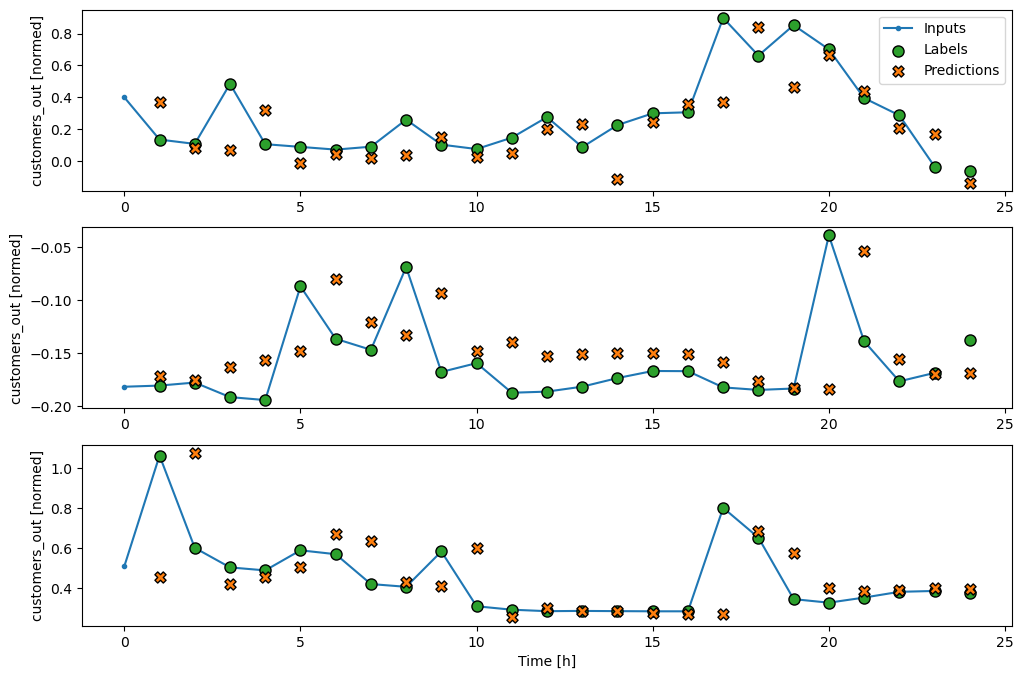

In [168]:
wide_window.plot(lstm_model)

Performance:

In [169]:
cm = lstm_model.metrics[1]
cm.metrics

[<MeanAbsoluteError name=mean_absolute_error>]

In [170]:
val_performance

{'Baseline': {'loss': 0.23522353172302246,
  'mean_absolute_error': 0.10816974937915802},
 'Linear': {'loss': 0.23178376257419586,
  'mean_absolute_error': 0.10952405631542206},
 'Multi step dense': {'loss': 0.2716919481754303,
  'mean_absolute_error': 0.1256595104932785},
 'Conv': {'loss': 0.41674596071243286,
  'mean_absolute_error': 0.15120095014572144},
 'LSTM': {'loss': 0.3391636610031128,
  'mean_absolute_error': 0.1357819139957428}}

### Change column name here

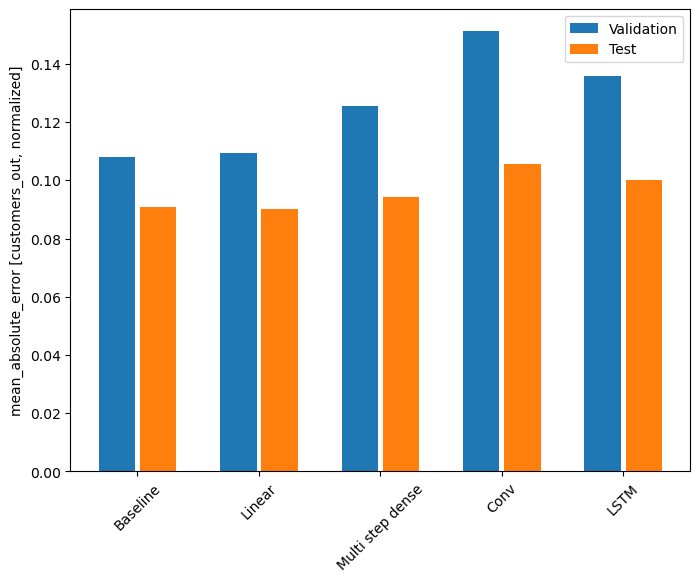

In [171]:
x = np.arange(len(performance))
width = 0.3
metric_name = 'mean_absolute_error'
val_mae = [v[metric_name] for v in val_performance.values()]
test_mae = [v[metric_name] for v in performance.values()]

plt.ylabel('mean_absolute_error [customers_out, normalized]')
plt.bar(x - 0.17, val_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=performance.keys(),
           rotation=45)
_ = plt.legend()

In [172]:
for name, value in performance.items():
  print(f'{name:12s}: {value[metric_name]:0.4f}')

Baseline    : 0.0909
Linear      : 0.0901
Multi step dense: 0.0943
Conv        : 0.1056
LSTM        : 0.1002
